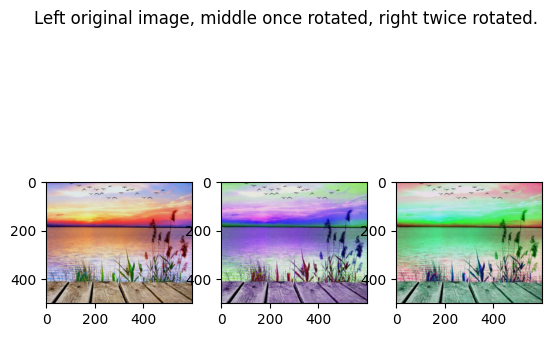

In [5]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

class RotatingImage():
    def __init__(self):
        # find the file on a student computer and make it operating system insensitive.
        path = Path.cwd()
        path = path.glob('**/sunset.png').__next__()

        # load image
        with Image.open(path) as img:
            self.img = np.array(img)
    
    def rotate_color(self):
        """
        Rotate the color channels of the image.
        - Red → Green
        - Green → Blue
        - Blue → Red
        """
        # Create a temporary copy of the red channel.
        tmp = self.img[:, :, [0]]  # Select the red channel.

        # Swap red and green channels.
        self.img[:, :, 0], self.img[:, :, 1] = self.img[:, :, 1], self.img[:, :, 2]

        # Replace the blue channel with the original red channel.
        self.img[:, :, 2] = tmp[:, :, 0]

    def plot_image(self):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
        fig.suptitle("Left original image, middle once rotated, right twice rotated.")
        axs = (ax1, ax2, ax3)
        for ax in axs:
            ax.imshow(self.img, vmin=0, vmax=255)
            self.rotate_color()
        plt.show()

if __name__ == "__main__":
    img = RotatingImage()
    img.plot_image()